In [1]:
#Q1
import pandas as pd

# load dataset
df = pd.read_csv("house_sales_data.csv")

# display data types of each column
print(df.dtypes)

Unnamed: 0         int64
id                 int64
date              object
price            float64
bedrooms         float64
bathrooms        float64
sqft_living        int64
sqft_lot           int64
floors           float64
waterfront         int64
view               int64
condition          int64
grade              int64
sqft_above         int64
sqft_basement      int64
yr_built           int64
yr_renovated       int64
zipcode            int64
lat              float64
long             float64
sqft_living15      int64
sqft_lot15         int64
dtype: object


In [6]:
# Q2
df.drop(["id","Unnamed: 0"], axis=1, inplace=True)

df.describe()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
count,2.161300e+04,21600.000000,21603.000000,21613.000000,2.161300e+04,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000
mean,5.400881e+05,3.372870,2.115736,2079.899736,1.510697e+04,1.494309,0.007542,0.234303,3.409430,7.656873,1788.390691,291.509045,1971.005136,84.402258,98077.939805,47.560053,-122.213896,1986.552492,12768.455652
std,3.671272e+05,0.926657,0.768996,918.440897,4.142051e+04,0.539989,0.086517,0.766318,0.650743,1.175459,828.090978,442.575043,29.373411,401.679240,53.505026,0.138564,0.140828,685.391304,27304.179631
min,7.500000e+04,1.000000,0.500000,290.000000,5.200000e+02,1.000000,0.000000,0.000000,1.000000,1.000000,290.000000,0.000000,1900.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,3.219500e+05,3.000000,1.750000,1427.000000,5.040000e+03,1.000000,0.000000,0.000000,3.000000,7.000000,1190.000000,0.000000,1951.000000,0.000000,98033.000000,47.471000,-122.328000,1490.000000,5100.000000
50%,4.500000e+05,3.000000,2.250000,1910.000000,7.618000e+03,1.500000,0.000000,0.000000,3.000000,7.000000,1560.000000,0.000000,1975.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,6.450000e+05,4.000000,2.500000,2550.000000,1.068800e+04,2.000000,0.000000,0.000000,4.000000,8.000000,2210.000000,560.000000,1997.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000
max,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,1.000000,4.000000,5.000000,13.000000,9410.000000,4820.000000,2015.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000


In [7]:

# Q3
floor_counts = df['floors'].value_counts().to_frame()

floor_counts

,count
floors,
1.0,10680
2.0,8241
1.5,1910
3.0,613
2.5,161
3.5,8


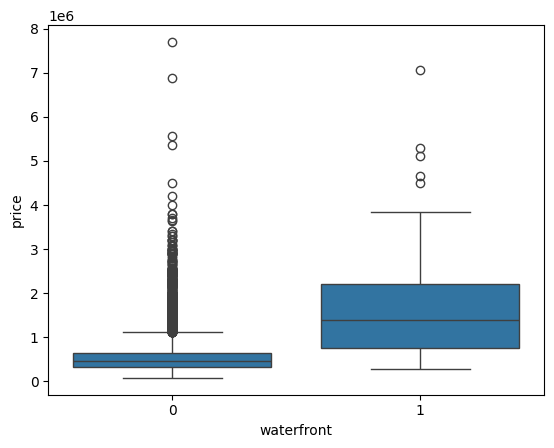

In [8]:
# q4
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x="waterfront", y="price", data=df)

plt.show()

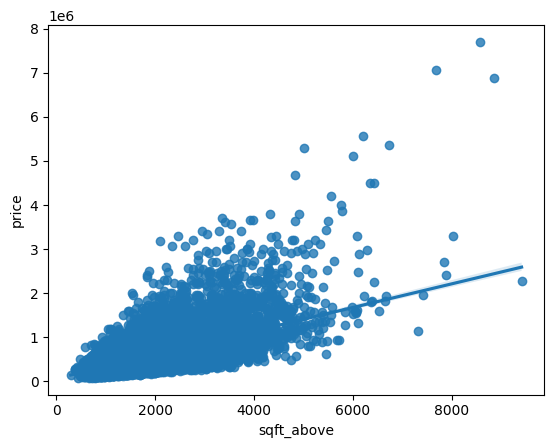

R^2 = 0.4928532179037931


In [11]:
# q5
from sklearn.linear_model import LinearRegression
sns.regplot(x="sqft_above", y="price", data=df)

plt.show()
lm = LinearRegression()

X = df[['sqft_living']]
Y = df['price']

lm.fit(X,Y)

r2 = lm.score(X,Y)

print("R^2 =", r2)

In [13]:
from sklearn.linear_model import LinearRegression

features = [
"floors",
"waterfront",
"lat",
"bedrooms",
"sqft_basement",
"view",
"bathrooms",
"sqft_living15",
"sqft_above",
"grade",
"sqft_living"
]

# Fix NaN values
df[features] = df[features].fillna(df[features].mean())

X = df[features]
Y = df['price']

lm = LinearRegression()

lm.fit(X,Y)

print("R^2 =", lm.score(X,Y))

R^2 = 0.6576951666037502


In [14]:
# q8
features = [
"floors",
"waterfront",
"lat",
"bedrooms",
"sqft_basement",
"view",
"bathrooms",
"sqft_living15",
"sqft_above",
"grade",
"sqft_living"
]

X = df[features]
Y = df['price']

lm.fit(X,Y)

print("R^2 =", lm.score(X,Y))

R^2 = 0.6576951666037502


In [15]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression

# features given in the previous question
features = [
"floors",
"waterfront",
"lat",
"bedrooms",
"sqft_basement",
"view",
"bathrooms",
"sqft_living15",
"sqft_above",
"grade",
"sqft_living"
]

X = df[features]
Y = df['price']

# handle missing values
X = X.fillna(X.mean())

# create pipeline
pipe = Pipeline([
    ('scale', StandardScaler()),
    ('polynomial', PolynomialFeatures(degree=2)),
    ('model', LinearRegression())
])

# fit the model
pipe.fit(X, Y)

# calculate R²
r2 = pipe.score(X, Y)

print("R^2 =", r2)

R^2 = 0.7513408515988734


In [16]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge

# features from the previous question
features = [
"floors",
"waterfront",
"lat",
"bedrooms",
"sqft_basement",
"view",
"bathrooms",
"sqft_living15",
"sqft_above",
"grade",
"sqft_living"
]

X = df[features]
Y = df['price']

# handle missing values
X = X.fillna(X.mean())

# split data into training and testing sets
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=1)

# create Ridge regression model
ridge_model = Ridge(alpha=0.1)

# fit model using training data
ridge_model.fit(X_train, Y_train)

# calculate R² using test data
r2 = ridge_model.score(X_test, Y_test)

print("R^2 =", r2)

R^2 = 0.6459152254891434


In [17]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge

# polynomial transformation (degree 2)
poly = PolynomialFeatures(degree=2)

# transform training and testing data
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

# create Ridge regression model
ridge = Ridge(alpha=0.1)

# fit model using training data
ridge.fit(X_train_poly, Y_train)

# calculate R² using test data
r2 = ridge.score(X_test_poly, Y_test)

print("R^2 =", r2)

R^2 = 0.7543633734805864
